# Transformer Full Training and PEFT Training Tradeoffs Analysis

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
base_path = Path.cwd().parent
base_path

bert_df = pd.read_csv(base_path/"data"/"transformer_models"/"bert_df.csv")
distilbert_df = pd.read_csv(base_path/"data"/"transformer_models"/"distilbert_df.csv")

full_train_df = pd.read_csv(base_path/"data"/"distilbert_df.csv")
peft_df = pd.read_csv(base_path/"data"/"peft_distilbert_df.csv")

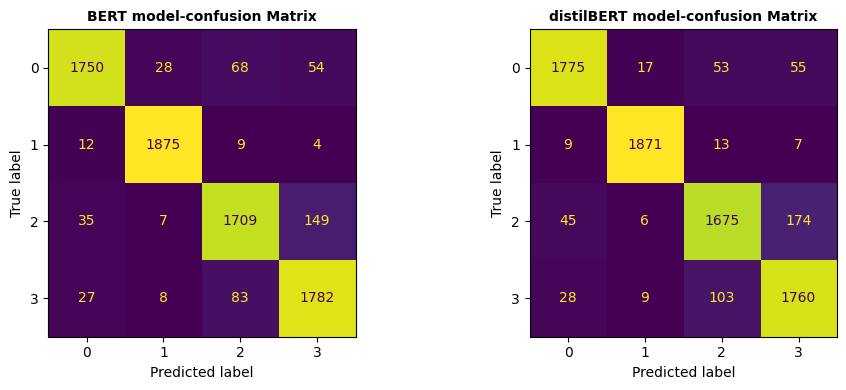

In [3]:
cm_bert = confusion_matrix(bert_df['labels'], bert_df['predictions'], labels=[0, 1, 2, 3])
cm_distilbert = confusion_matrix(distilbert_df['labels'], distilbert_df['predictions'], labels=[0, 1, 2, 3])

fig, ax = plt.subplots(1, 2, figsize=[10,4], layout='tight')
cm_plot_bert =ConfusionMatrixDisplay(cm_bert)
cm_plot_bert.plot(colorbar=False, ax=ax[0])
ax[0].set_title("BERT model-confusion Matrix", fontsize=10, fontweight='bold')

cm_plot_distilbert =ConfusionMatrixDisplay(cm_distilbert)
cm_plot_distilbert.plot(colorbar=False, ax=ax[1])
ax[1].set_title("distilBERT model-confusion Matrix", fontsize=10, fontweight='bold')

plt.show()

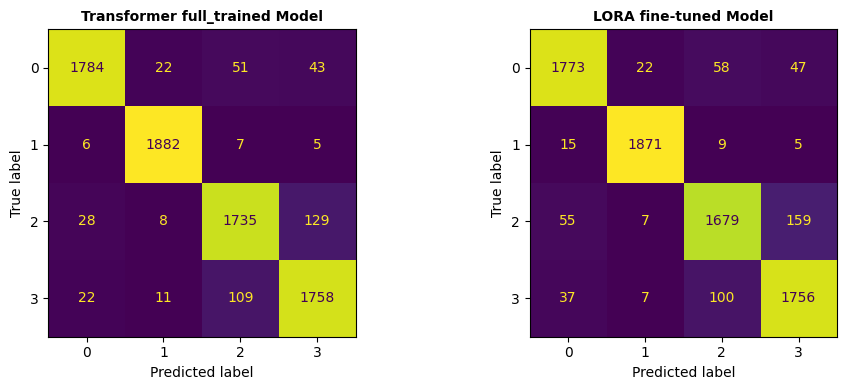

In [4]:
cm_full_train = confusion_matrix(full_train_df['labels'], 
                                 full_train_df['predictions'], 
                                 labels=[0,1,2,3])

cm_peft = confusion_matrix(peft_df['labels'], 
                           peft_df['predictions'], 
                           labels=[0, 1, 2, 3]
                          )

fig, ax = plt.subplots(1, 2, figsize=[10,4], layout='tight')
cm_plot_ft =ConfusionMatrixDisplay(cm_full_train)
cm_plot_ft.plot(colorbar=False, ax=ax[0])
ax[0].set_title("Transformer full_trained Model", fontsize=10, fontweight='bold')

cm_plot_peft =ConfusionMatrixDisplay(cm_peft)
cm_plot_peft.plot(colorbar=False, ax=ax[1])
ax[1].set_title("LORA fine-tuned Model", fontsize=10, fontweight='bold')

plt.show()

The predictive accuracy of each class are not equally distributed although both models' accuracy are similar. The poorest predictive performance was in class label 2 and the best performing was in class label 1. An important insight from the confusion matrix display above include: 
1. The class label 1 has the least false positive and false negative predictions.
2. The class labels 2 and 3 were the highest class where the labels were confused and classed as the other.

### Model metrics comparisons

In [5]:
bert_test_metrics_path = base_path/"results"/"transformer_models"/"bert"/"test_metrics.json"
bert_train_time_path = base_path/"results"/"transformer_models"/"bert"/"train_time.json"

distil_test_metrics_path = base_path/"results"/"transformer_models"/"distilbert"/"test_metrics.json"
distil_train_time_path = base_path/"results"/"transformer_models"/"distilbert"/"train_time.json"

In [6]:
def load_metrics(path): 
    with open(path) as p:
        return json.load(p)

bert_model_metrics = load_metrics(bert_test_metrics_path)
bert_train_time = load_metrics(bert_train_time_path)
distilbert_model_metrics = load_metrics(distil_test_metrics_path)
distilbert_train_time = load_metrics(distil_train_time_path) 


## updating contents of the dictionary 
distilbert_train_time
del bert_model_metrics['cm'] 
del distilbert_model_metrics['cm']

bert_model_metrics["prediction_time"] = bert_model_metrics.pop("inference_time")
distilbert_model_metrics["prediction_time"] = distilbert_model_metrics.pop("inference_time")

bert_model_metrics["Training_time"] = bert_train_time["Training_time"]
distilbert_model_metrics["Training_time"] = distilbert_train_time["Training_time"]

bert_model_metrics["model"] = "bert"
distilbert_model_metrics["model"] = "distilbert"

In [7]:
pd.DataFrame([bert_model_metrics, distilbert_model_metrics]).set_index("model")

,accuracy,precision,recall,f1,num_of_params,prediction_time,Training_time
model,,,,,,,
bert,0.936316,0.936316,0.936316,0.936316,109485316,535.396,30810.603
distilbert,0.931711,0.931711,0.931711,0.931711,66956548,261.826,25714.772


#### Summary
Both Bert and distilBert model performances are similar for the AG-News dataset. The BERT model has more trainable parameters compared to the distilBERT model. But this is as expected because distilbert is a smaller, faster and distilled version of the BERT model.  Therefore the increase in training and prediction time as well as the slight increase in performance parameters for the BERT model is as expected for the model. 

## Recommendation
It can be seen from the confusion matrix performances, sequence length performances and test metrics that the BERT model performed more than the distilBERT model by a very minimal margin.  However, this came at the cost of higher training parameters, train time and prediction time which overall require more compute resources.  The marginal improvement does not compensate for the extra cost incurred by the BERT model.  Therefore, from a business objective, I will recommend the deployment and use of the distilBERT model over the BERT model. 

## PEFT vs Full fine-tuning performance comparisons

In [8]:
ft_test_metrics_path = base_path/'results'/'distilbert'/'test_metrics.json'
ft_train_time = base_path/'results'/'distilbert'/'train_time.json'  

peft_train_time = base_path/'results'/'peft'/'distilbert'/'peft_train_time.json'
peft_test_metrics = base_path/'results'/'peft'/'distilbert'/'peft_test_metrics.json'
peft_params = base_path/'results'/'peft'/'distilbert'/'peft_params.json'

ft_test_metrics = load_metrics(ft_test_metrics_path)
ft_train_time = load_metrics(ft_train_time)

peft_train_time = load_metrics(peft_train_time)
peft_test_metrics = load_metrics(peft_test_metrics)
peft_params = load_metrics(peft_params)

del peft_test_metrics['cm']
del ft_test_metrics['cm']

peft_test_metrics["training_time"] = peft_train_time["Training_time"]
ft_test_metrics["training_time"] = ft_train_time["Training_time"]
peft_test_metrics["model_type"] = "PEFT_distilbert"
ft_test_metrics["model_type"] = "FT_distilbert"

model_metrics = pd.DataFrame([peft_test_metrics, ft_test_metrics]).set_index("model_type")
model_metrics

,accuracy,precision,recall,f1,inference_time,num_of_params,training_time
model_type,,,,,,,
PEFT_distilbert,0.931447,0.931447,0.931447,0.931447,22.884,67697672,6250.328
FT_distilbert,0.941974,0.941974,0.941974,0.941974,24.362,66956548,8520.363


### Number of trainable parameters for PEFT model 

In [9]:
peft_param_path = base_path/"results"/"peft"/"distilbert"/"peft_params.json"

peft_trainable_params = load_metrics(peft_param_path)
pd.DataFrame(peft_trainable_params, index=["Peft_distilbert_Model"])

,trainable_params,all_params,trainable_percentage
Peft_distilbert_Model,741124,67697672,1.094756


## Conclusion 

The performance of the  full trained transformer  and the PEFT trained are comparable as expected because both training types are using the same transformer model.  However, the compute memory and time are significantly different  between a fully trained transformer y and the PEFT trained transformer with only approximately 1% of the entire parameters trainable with PEFT model.   Therefore the 1% gain in performance for a fully trained transformer does not fully compensate for the cost in time, compute power and resources used in training the model.  Finally, the size of the PEFT trained model is approx 4MB which is significantly smaller than the fully trained model which is 256MB in size. 